# 03: Partially Linear Regression PLR

This lesson is a full tutorial on the `DoubleMLPLR` model: the partially linear regression design for a continuous treatment.

The goal is more than to call an API. The goal is to understand the causal target, the nuisance functions, the orthogonal score, the cross-fitting logic, the diagnostics, and the reporting caveats that make the estimate credible.

We will work with a synthetic example dataset where the true treatment effect is known. That lets us see exactly what goes wrong with naive regression and why residualization plus orthogonalization is useful. In a real application the true effect is unknown, so the same workflow would focus on design assumptions, nuisance diagnostics, uncertainty, and robustness.

## Learning Goals

By the end, you should be able to:

- State the PLR estimand in words and equations.
- Explain why the treatment and outcome nuisance functions matter.
- Recognize the difference between naive prediction adjustment and Neyman-orthogonal estimation.
- Manually compute the residual-on-residual PLR estimate using cross-fitted nuisance predictions.
- Fit `DoubleMLPLR` with flexible learners.
- Read coefficients, standard errors, confidence intervals, nuisance losses, and split-stability diagnostics.
- Write a short, honest report for a PLR estimate.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Partially Linear Regression PLR**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment uses a partially linear structure to isolate one treatment parameter while allowing high-dimensional or nonlinear nuisance functions.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

The partially linear regression model writes

$$
Y=\theta_0D+g_0(X)+\varepsilon, \qquad \mathbb{E}(\varepsilon\mid D,X)=0,
$$

with treatment nuisance function

$$
D=m_0(X)+V, \qquad \mathbb{E}(V\mid X)=0.
$$

DoubleML estimates $g_0$ and $m_0$, forms residuals $\widetilde Y=Y-\widehat g(X)$ and $\widetilde D=D-\widehat m(X)$, then estimates $\theta_0$ from the residualized relationship.





## Tutorial Workflow

#### Where PLR Fits

`DoubleMLPLR` is appropriate when the treatment is continuous or can be reasonably treated as a continuous dose, and the causal effect is represented by a constant slope after adjusting for observed covariates.

Examples of PLR-style questions include:

- What is the average effect of one additional unit of exposure intensity on a future user outcome, after adjusting for user history?
- What is the effect of a pricing, ranking, or messaging intensity score on demand, after adjusting for baseline demand predictors?
- What is the effect of a continuous operational intervention on a downstream metric, after adjusting for the variables that influenced the intervention?

The model is called partially linear because the treatment enters linearly, while the relationship between covariates and both the outcome and treatment can be flexible and nonlinear.

### The PLR Model

The standard partially linear regression model is:

$$
Y = \theta_0 D + g_0(X) + \zeta, \quad E[\zeta \mid D, X] = 0
$$

and the treatment equation is:

$$
D = m_0(X) + V, \quad E[V \mid X] = 0
$$

Here:

- `Y` is the outcome.
- `D` is the continuous treatment or dose.
- `X` is the set of observed controls.
- `theta_0` is the target causal slope.
- `g_0(X)` is the outcome nuisance function.
- `m_0(X)` is the treatment nuisance function.
- `V` is the part of treatment variation not explained by controls.

The identifying idea is that, after controlling for `X`, the remaining variation in `D` behaves as good-as-random for estimating the slope on `Y`. DoubleML does not make that assumption true; the analyst has to defend it through the causal design.




## Diagnostics and Interpretation

### Orthogonal Score Intuition

The partialling-out score used in this lesson is:

$$
\psi(W; \theta, \eta) = (D - m(X)) \{Y - l(X) - \theta(D - m(X))\}
$$

where `l(X) = E[Y | X]`, `m(X) = E[D | X]`, and `eta = (l, m)` are nuisance functions.

This score creates two residuals:

- treatment residual: `D - m(X)`
- outcome residual: `Y - l(X)`

Then it estimates `theta` from the relationship between the residualized outcome and residualized treatment.

The important theoretical feature is Neyman orthogonality: small first-order errors in the nuisance functions have little first-order impact on the treatment-effect estimate. That is what allows flexible machine-learning models to be used for nuisance estimation without directly turning prediction bias into treatment-effect bias.



### Practical Runtime Note

This lesson fits several cross-fitted nuisance models. On a typical laptop, the full notebook should take roughly one to three minutes. The heaviest cells are the gradient-boosting PLR fits and the manual cross-fitting cell.

The examples are intentionally moderate in size. They are large enough to show the behavior of the estimators but small enough to keep the tutorial easy to rerun.

#### Setup

The code below prepares the notebook environment. It creates output folders, makes matplotlib cache writes local to the tutorial folder, imports the scientific Python stack, and records package versions for reproducibility.

The path logic supports two common ways of running the notebook: from the repository root or directly from the tutorial folder.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings

NOTEBOOK_PREFIX = "03"
RANDOM_STATE = 2026

CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "doubleml":
    REPO_ROOT = CURRENT_DIR.parents[2]
elif (CURRENT_DIR / "notebooks" / "tutorials" / "doubleml").exists():
    REPO_ROOT = CURRENT_DIR
else:
    REPO_ROOT = CURRENT_DIR

OUTPUT_DIR = REPO_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLPLR

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

package_versions = pd.DataFrame(
    [
        {"package": "doubleml", "version": dml.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "seaborn", "version": sns.__version__},
        {"package": "statsmodels", "version": sm.__version__},
    ]
)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,doubleml,0.11.2
1,numpy,2.4.4
2,pandas,3.0.2
3,seaborn,0.13.2
4,statsmodels,0.14.6


The package table is more than bookkeeping. In causal ML tutorials, reproducibility depends on both the statistical design and the software versions, especially when cross-fitting and tree-based learners are involved.

#### Helper Functions

The next cell defines small helper functions used throughout the notebook. Keeping these utilities in one place makes the analysis cells easier to read.

The functions do four jobs:

- Save tables with consistent names.
- Compute regression summaries for simple OLS baselines.
- Compute PLR estimates from residuals.
- Pull DoubleML predictions and learner losses into tidy tables.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, name):
    """
    Save a dataframe to the tutorial table directory and return it for display.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    name : str
        Short artifact or scenario name used for saving and labeling outputs.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / f"{NOTEBOOK_PREFIX}_{name}.csv"
    df.to_csv(path, index=False)
    return df


def regression_summary(y, X, treatment_col, label):
    """
    Fit an HC1-robust OLS model and return the treatment coefficient row.
    
    Parameters
    ----------
    y : str or array-like
        Second variable, outcome, or numeric input in the local calculation.
    X : object
        Covariate matrix used by the estimator, learner, or intervention function.
    treatment_col : str
        Treatment or intervention column name.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    dict[str, float]
        Regression summary row with treatment estimate, standard error, confidence interval, and p-value.
    """
    X_design = sm.add_constant(X, has_constant="add")
    fit = sm.OLS(y, X_design).fit(cov_type="HC1")
    row = fit.summary2().tables[1].loc[treatment_col]
    return {
        "estimator": label,
        "theta_hat": row["Coef."],
        "std_error": row["Std.Err."],
        "ci_95_lower": row["[0.025"],
        "ci_95_upper": row["0.975]"],
        "p_value": row["P>|z|"],
        "r_squared": fit.rsquared,
    }


def plr_from_residuals(y_resid, d_resid, label):
    """
    Compute the partialling-out estimate and large-sample standard error.
    
    Parameters
    ----------
    y_resid : object
        Outcome residual after removing the fitted nuisance component.
    d_resid : object
        Treatment residual after removing the fitted nuisance component.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    dict[str, float]
        Manual PLR summary row from residualized outcome and treatment regressions.
    """
    y_resid = np.asarray(y_resid)
    d_resid = np.asarray(d_resid)
    n_obs = len(y_resid)
    theta_hat = float(np.sum(d_resid * y_resid) / np.sum(d_resid ** 2))
    score = d_resid * (y_resid - theta_hat * d_resid)
    derivative = -np.mean(d_resid ** 2)
    std_error = float(np.sqrt(np.mean(score ** 2) / (derivative ** 2 * n_obs)))
    return {
        "estimator": label,
        "theta_hat": theta_hat,
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
    }


def prediction_vector(doubleml_model, learner_key):
    """
    Extract the first treatment and first repetition prediction vector.
    
    Parameters
    ----------
    doubleml_model : object
        Model object used for `doubleml` in `prediction_vector`.
    learner_key : object
        Dictionary key identifying the learner configuration being evaluated.
    
    Returns
    -------
    np.ndarray
        One-dimensional prediction array aligned with the evaluation rows.
    """
    arr = np.asarray(doubleml_model.predictions[learner_key])
    if arr.ndim != 3:
        raise ValueError(f"Expected a 3D prediction array, got shape {arr.shape}")
    return arr[:, 0, 0]


def learner_loss_table(doubleml_model, model_label):
    """
    Convert DoubleML learner evaluation arrays into a tidy dataframe.
    
    Parameters
    ----------
    doubleml_model : object
        Model object used for `doubleml` in `learner_loss_table`.
    model_label : str
        Readable label for `model`.
    
    Returns
    -------
    pd.DataFrame
        Out-of-fold nuisance prediction loss table by learner and nuisance role.
    """
    losses = doubleml_model.evaluate_learners()
    rows = []
    for learner_name, values in losses.items():
        arr = np.asarray(values)
        rows.append(
            {
                "model": model_label,
                "learner": learner_name,
                "mean_rmse": float(np.mean(arr)),
                "min_rmse": float(np.min(arr)),
                "max_rmse": float(np.max(arr)),
            }
        )
    return pd.DataFrame(rows)


def rmse(y_true, y_pred):
    """
    Idea: Compute root mean squared error between an oracle target and an estimated or predicted value.
    
    Parameters
    ----------
    y_true : array-like
        Reference outcome, oracle value, or known target used for evaluation.
    y_pred : array-like
        Predicted outcome or estimated value being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


These helpers are intentionally transparent. A strong applied notebook should make the statistical calculations visible enough that the reader can connect the package output to the underlying estimand.

#### Create an Example Dataset

We now simulate a continuous-treatment causal problem. The covariates are named like ordinary product or marketplace features, but the data are synthetic.

The treatment is `exposure_intensity`. It is not randomly assigned. It depends on observed user/context features through a nonlinear treatment rule. The outcome is `weekly_value`, and it depends on both the treatment and the same observed features.

Because the outcome nuisance function is correlated with the treatment rule, a naive regression of outcome on treatment will be biased.

In [3]:
# Save the artifacts produced by the Create An Example Dataset section.
rng = np.random.default_rng(RANDOM_STATE)
N_OBS = 3_000
TRUE_THETA = 1.75

feature_cols = [
    "engagement_score",
    "need_intensity",
    "content_fit",
    "recent_activity",
    "price_sensitivity",
    "tenure_signal",
    "novelty_appetite",
    "seasonality_signal",
]

X_raw = pd.DataFrame(rng.normal(size=(N_OBS, len(feature_cols))), columns=feature_cols)

true_m = (
    0.90 * X_raw["engagement_score"]
    + 0.70 * np.sin(X_raw["need_intensity"])
    + 0.40 * X_raw["content_fit"] ** 2
    - 0.30 * X_raw["recent_activity"] * X_raw["price_sensitivity"]
    + 0.40 * X_raw["tenure_signal"]
)

additional_outcome_signal = (
    0.50 * np.sin(X_raw["engagement_score"] * X_raw["content_fit"])
    + 0.30 * X_raw["novelty_appetite"] ** 2
    - 0.40 * X_raw["seasonality_signal"]
)

true_g = 1.40 * true_m + additional_outcome_signal
true_l = TRUE_THETA * true_m + true_g

treatment_noise = rng.normal(loc=0.0, scale=1.00, size=N_OBS)
outcome_noise = rng.normal(loc=0.0, scale=1.00, size=N_OBS)

exposure_intensity = true_m + treatment_noise
weekly_value = TRUE_THETA * exposure_intensity + true_g + outcome_noise

plr_df = X_raw.assign(
    exposure_intensity=exposure_intensity,
    weekly_value=weekly_value,
    true_treatment_nuisance=true_m,
    true_outcome_nuisance=true_l,
    true_structural_g=true_g,
    treatment_noise=treatment_noise,
    outcome_noise=outcome_noise,
)

plr_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_plr_data.csv", index=False)
print(f"Saved synthetic PLR data with shape {plr_df.shape}")
display(plr_df.head())


Saved synthetic PLR data with shape (3000, 15)


,engagement_score,need_intensity,content_fit,recent_activity,price_sensitivity,tenure_signal,novelty_appetite,seasonality_signal,exposure_intensity,weekly_value,true_treatment_nuisance,true_outcome_nuisance,true_structural_g,treatment_noise,outcome_noise
0,-0.793122,0.240571,-1.896326,1.395772,0.638295,-0.292047,-0.311949,0.303835,1.868234,4.156543,0.507298,2.004535,1.116763,1.360936,-0.229630
1,-0.267660,-0.225909,0.720068,0.514705,-0.064128,-0.085477,0.160916,-0.614018,0.282119,0.478083,-0.214578,-0.518317,-0.142805,0.496698,0.127180
2,-0.403750,0.548260,-0.130483,-1.374426,-0.477279,0.656622,-0.232283,-0.148733,-0.142787,-1.041454,0.074131,0.335520,0.205792,-0.216918,-0.997368
3,0.641837,1.824610,-0.713189,1.348207,-1.230013,0.174978,-1.169530,1.351458,1.629943,7.079294,2.026166,6.031214,2.485423,-0.396223,1.741472
4,0.833923,1.137717,-0.885533,0.684555,-0.519013,-0.457385,0.506537,0.876718,0.848602,4.009787,1.623206,4.502810,1.662198,-0.774604,0.862535


The saved dataset includes both the observable columns and hidden teaching columns such as the true nuisance functions. In real data those true nuisance functions are not available. They are included here only so we can check whether each estimator behaves as expected.

#### Field Dictionary

Before modeling, we document the columns. This is a small habit with a large payoff: causal workflows depend on roles. A column is more than a feature; it may be an outcome, treatment, pre-treatment control, generated diagnostic, or hidden simulation quantity.

| column | role | description |
| --- | --- | --- |
| weekly_value | outcome | Observed outcome Y. |
| exposure_intensity | continuous treatment | Observed treatment or dose D. |
| engagement_score | control | Pre-treatment engagement signal. |
| need_intensity | control | Pre-treatment need or demand signal. |
| content_fit | control | Pre-treatment content or product fit signal. |
| recent_activity | control | Pre-treatment recent activity signal. |
| price_sensitivity | control | Pre-treatment sensitivity signal. |
| tenure_signal | control | Pre-treatment tenure signal. |
| novelty_appetite | control | Pre-treatment novelty preference signal. |
| seasonality_signal | control | Pre-treatment seasonal/context signal. |
| true_treatment_nuisance | hidden teaching column | True m0(X) used only for diagnostics in synthetic data. |
| true_outcome_nuisance | hidden teaching column | True l0(X) = E[Y \| X] used only for diagnostics in synthetic data. |
| true_structural_g | hidden teaching column | True g0(X) in the structural outcome equation. |
| treatment_noise | hidden teaching column | Unexplained treatment variation V. |
| outcome_noise | hidden teaching column | Outcome disturbance zeta. |


The controls are all pre-treatment by construction. That matters because PLR adjusts for `X`; including post-treatment variables would change the estimand and can block part of the treatment effect.



### Basic Data Audit

The next cell checks shape, missingness, basic moments, and the observed correlation between treatment and outcome.

A data audit catches ordinary failures before we spend time interpreting an estimator: missing values, constant variables, implausible scales, or a treatment with too little variation. Identification still comes from the study design.

In [4]:
audit_rows = []
for column in ["weekly_value", "exposure_intensity"] + feature_cols:
    s = plr_df[column]
    audit_rows.append(
        {
            "column": column,
            "missing_rate": float(s.isna().mean()),
            "mean": float(s.mean()),
            "std": float(s.std()),
            "min": float(s.min()),
            "p05": float(s.quantile(0.05)),
            "median": float(s.median()),
            "p95": float(s.quantile(0.95)),
            "max": float(s.max()),
            "n_unique": int(s.nunique()),
        }
    )

data_audit = pd.DataFrame(audit_rows)
save_table(data_audit, "data_audit")
display(data_audit)

observed_corr = plr_df[["weekly_value", "exposure_intensity"]].corr().iloc[0, 1]
print(f"Observed treatment-outcome correlation: {observed_corr:.3f}")
print(f"True theta used in the simulation: {TRUE_THETA:.2f}")


,column,missing_rate,mean,std,min,p05,median,p95,max,n_unique
0,weekly_value,0.0,1.430433,4.539450,-13.456512,-5.672829,1.376231,9.125022,19.897151,3000
1,exposure_intensity,0.0,0.379496,1.621467,-4.835908,-2.230475,0.389084,3.092460,7.074104,3000
2,engagement_score,0.0,-0.002931,1.014648,-3.659392,-1.684926,0.006120,1.604898,4.013439,3000
3,need_intensity,0.0,-0.018741,1.006393,-3.484637,-1.669852,-0.019327,1.662892,3.150908,3000
4,content_fit,0.0,0.012325,0.984224,-3.987716,-1.600982,0.024807,1.592880,3.600337,3000
5,recent_activity,0.0,-0.001487,1.003650,-3.573864,-1.600296,0.017822,1.671128,3.653308,3000
6,price_sensitivity,0.0,-0.001699,0.991457,-3.747414,-1.676108,0.026963,1.591078,3.417551,3000
7,tenure_signal,0.0,0.022647,1.021025,-3.586747,-1.670351,0.035436,1.706382,3.667511,3000
8,novelty_appetite,0.0,-0.000142,0.976362,-4.044650,-1.571103,-0.020953,1.613075,3.230977,3000
9,seasonality_signal,0.0,0.006351,1.011668,-3.272317,-1.633538,0.013726,1.678134,3.620951,3000


Observed treatment-outcome correlation: 0.935
True theta used in the simulation: 1.75


The treatment and outcome are strongly related in the raw data. That relationship is not automatically causal because the treatment was assigned based on covariates that also affect the outcome.



#### Visualize the Confounding Pattern

This figure has two panels.

The left panel shows the observed treatment-outcome relationship. The right panel shows how treatment intensity relates to the true treatment nuisance function, which is the part of treatment explained by observed controls.

In real data the true nuisance function is hidden. The simulation lets us see the confounding mechanism directly.

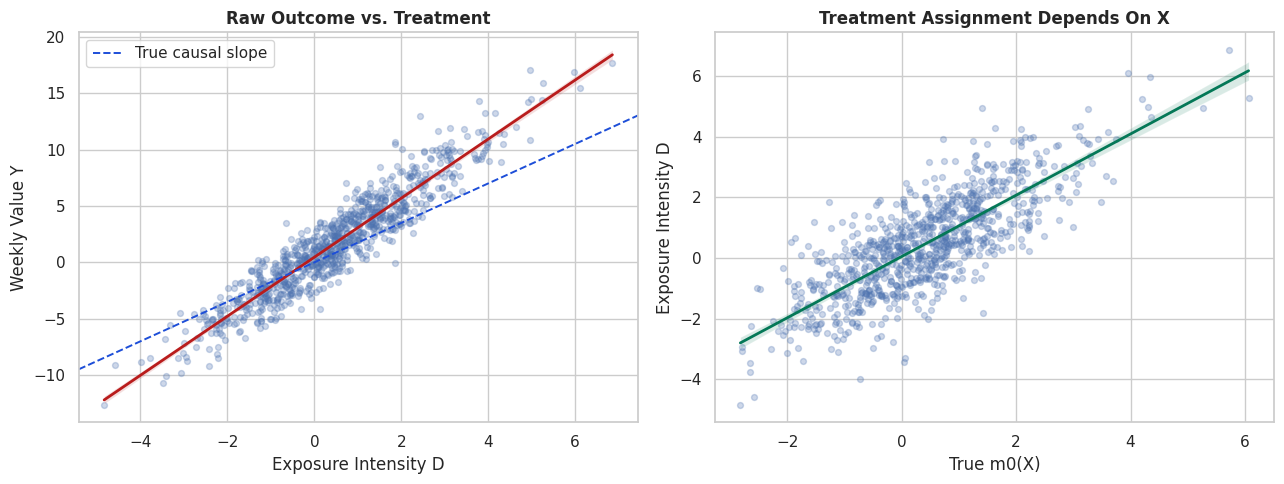

In [5]:
# Build and label the diagnostic visualization for the Visualize The Confounding Pattern section.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(
    data=plr_df.sample(900, random_state=RANDOM_STATE),
    x="exposure_intensity",
    y="weekly_value",
    scatter_kws={"alpha": 0.28, "s": 18},
    line_kws={"color": "#b91c1c", "linewidth": 2},
    ax=axes[0],
)
axes[0].axline((0, 0), slope=TRUE_THETA, color="#1d4ed8", linestyle="--", linewidth=1.4, label="True causal slope")
axes[0].set_title("Raw Outcome vs. Treatment")
axes[0].set_xlabel("Exposure Intensity D")
axes[0].set_ylabel("Weekly Value Y")
axes[0].legend()

sns.regplot(
    data=plr_df.sample(900, random_state=RANDOM_STATE),
    x="true_treatment_nuisance",
    y="exposure_intensity",
    scatter_kws={"alpha": 0.28, "s": 18},
    line_kws={"color": "#047857", "linewidth": 2},
    ax=axes[1],
)
axes[1].set_title("Treatment Assignment Depends On X")
axes[1].set_xlabel("True m0(X)")
axes[1].set_ylabel("Exposure Intensity D")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_raw_confounding_pattern.png", dpi=160, bbox_inches="tight")
plt.show()


The raw slope mixes two signals: the causal effect of treatment and the non-causal association created by the assignment rule. PLR tries to remove the part of treatment and outcome explained by controls before estimating the slope.



#### Design Correlation Matrix

The correlation matrix gives a quick, imperfect view of the data-generating structure. Linear correlations will miss some nonlinear relationships, but they still help us see which variables are visibly tied to treatment and outcome.

The hidden nuisance columns are included here for learning. In a real dataset, this plot would use only observed variables and engineered pre-treatment features.

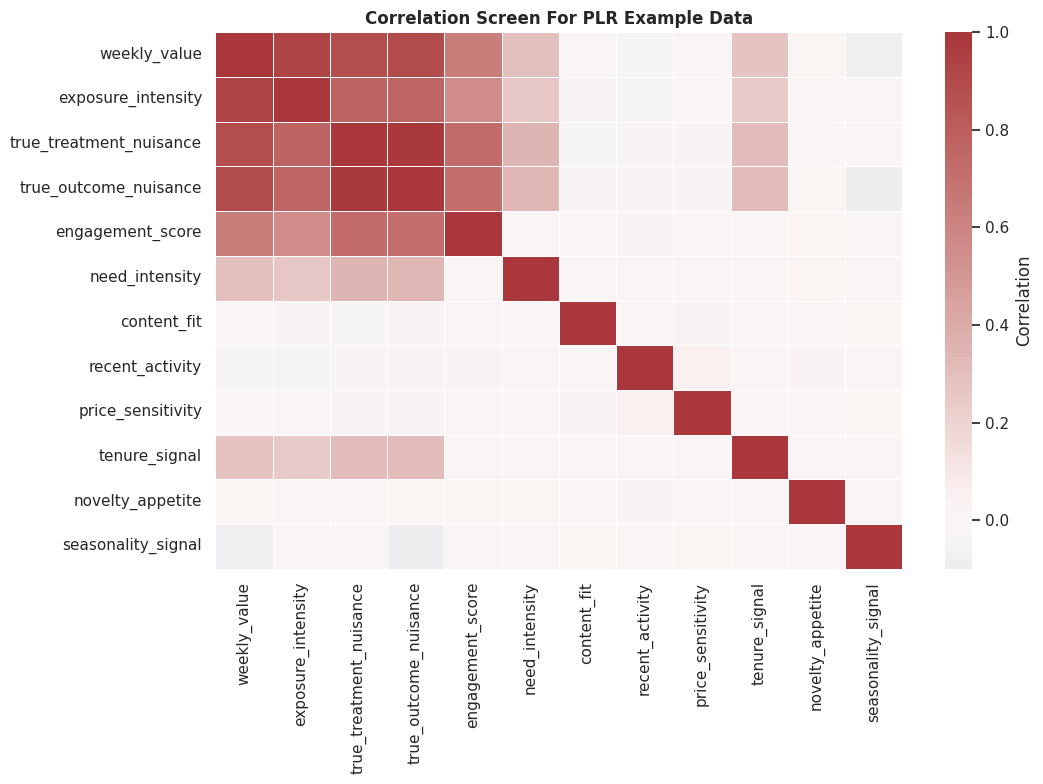

In [6]:
corr_cols = ["weekly_value", "exposure_intensity", "true_treatment_nuisance", "true_outcome_nuisance"] + feature_cols
corr_matrix = plr_df[corr_cols].corr()
save_table(corr_matrix.reset_index().rename(columns={"index": "column"}), "design_correlation_matrix")

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    annot=False,
    linewidths=0.4,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation Screen For PLR Example Data")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_design_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


The matrix shows why pure outcome prediction is not enough. Several controls are related to treatment and outcome, so a treatment-effect estimator has to separate assignment-driven variation from residual treatment variation.



#### Baseline Estimators

Before fitting DoubleML, we build simple baselines:

- `Naive OLS`: regress outcome only on treatment.
- `Linear adjustment OLS`: regress outcome on treatment and raw controls.
- `Oracle residual PLR`: residualize using the true nuisance functions from the simulation.

The oracle estimator is not available in real data. It is here to show the target behavior when residualization is perfect.

In [7]:
y = plr_df["weekly_value"].to_numpy()
d = plr_df["exposure_intensity"].to_numpy()
X = plr_df[feature_cols]

baseline_rows = []
baseline_rows.append(regression_summary(plr_df["weekly_value"], plr_df[["exposure_intensity"]], "exposure_intensity", "Naive OLS"))
baseline_rows.append(regression_summary(plr_df["weekly_value"], plr_df[["exposure_intensity"] + feature_cols], "exposure_intensity", "Linear adjustment OLS"))

oracle_y_resid = plr_df["weekly_value"].to_numpy() - plr_df["true_outcome_nuisance"].to_numpy()
oracle_d_resid = plr_df["exposure_intensity"].to_numpy() - plr_df["true_treatment_nuisance"].to_numpy()
baseline_rows.append(plr_from_residuals(oracle_y_resid, oracle_d_resid, "Oracle residual PLR"))

baseline_estimates = pd.DataFrame(baseline_rows)
baseline_estimates["true_theta"] = TRUE_THETA
baseline_estimates["bias_vs_truth"] = baseline_estimates["theta_hat"] - TRUE_THETA
save_table(baseline_estimates, "baseline_estimates")
display(baseline_estimates)


,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,r_squared,true_theta,bias_vs_truth
0,Naive OLS,2.616427,0.018387,2.580390,2.652464,0.0,0.873428,1.75,0.866427
1,Linear adjustment OLS,2.181194,0.023565,2.135007,2.227381,0.0,0.913228,1.75,0.431194
2,Oracle residual PLR,1.773986,0.016884,1.740894,1.807078,NaN,NaN,1.75,0.023986


The naive estimate is pulled away from the true effect because treatment intensity is higher for units with stronger expected outcomes. Linear adjustment improves the situation only if the raw linear controls approximate the true nuisance functions well. The oracle residual estimate shows the ideal target when the residualization step is correct.

#### Baseline Estimate Plot

The next plot turns the baseline table into a compact visual check. The dashed vertical line is the true treatment effect used in the simulation.

This kind of comparison is helpful in teaching settings. In real applications, replace the true-effect line with design-based sensitivity checks and transparent uncertainty reporting.

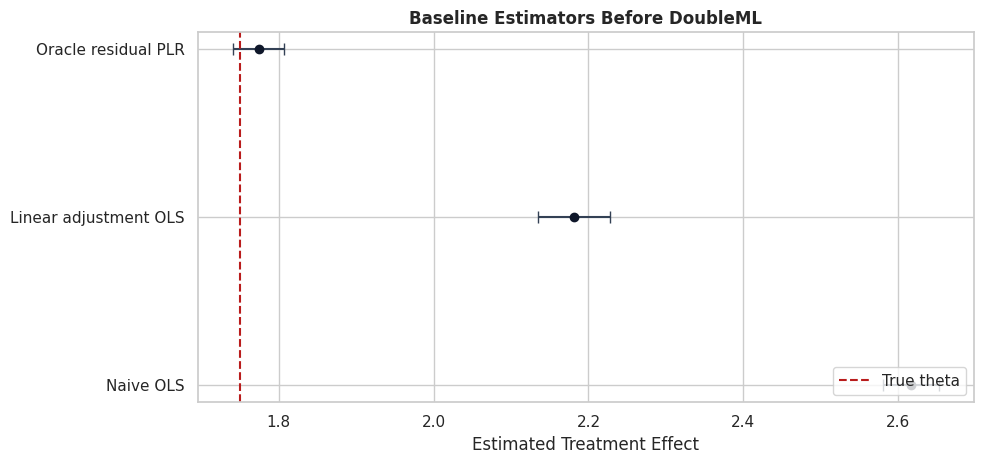

In [8]:
plot_baselines = baseline_estimates.copy()
plot_baselines["lower_error"] = plot_baselines["theta_hat"] - plot_baselines["ci_95_lower"]
plot_baselines["upper_error"] = plot_baselines["ci_95_upper"] - plot_baselines["theta_hat"]

fig, ax = plt.subplots(figsize=(10, 4.8))
y_pos = np.arange(len(plot_baselines))
ax.errorbar(
    x=plot_baselines["theta_hat"],
    y=y_pos,
    xerr=[plot_baselines["lower_error"], plot_baselines["upper_error"]],
    fmt="o",
    color="#0f172a",
    ecolor="#334155",
    capsize=4,
)
ax.axvline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.5, label="True theta")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_baselines["estimator"])
ax.set_xlabel("Estimated Treatment Effect")
ax.set_title("Baseline Estimators Before DoubleML")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the main motivation visible. A treatment-effect workflow should not stop at a raw slope. We need an estimator that uses flexible nuisance functions while preserving valid treatment-effect inference.

### Nuisance Learners for PLR

PLR needs two predictive models:

- `ml_l`: predicts the outcome from controls, `l(X) = E[Y | X]`.
- `ml_m`: predicts the treatment from controls, `m(X) = E[D | X]`.

The learners should be good enough to capture important confounding structure, but they are not the final object of interest. The final object is the orthogonal treatment-effect estimate.

We will use two learner families:

- a regularized linear model, useful as a transparent baseline;
- histogram gradient boosting, useful for nonlinear nuisance functions.

In [9]:
# Save the artifacts produced by the Nuisance Learners For PLR section.
linear_nuisance = make_pipeline(
    StandardScaler(),
    LassoCV(cv=3, random_state=RANDOM_STATE, max_iter=5_000),
)

gradient_boosting_nuisance = HistGradientBoostingRegressor(
    max_iter=220,
    learning_rate=0.05,
    max_leaf_nodes=24,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

learner_catalog = pd.DataFrame(
    [
        {
            "learner_name": "Regularized linear nuisance",
            "sklearn_object": type(linear_nuisance).__name__,
            "why_use_it": "Transparent baseline; fast; may underfit nonlinear nuisance functions.",
        },
        {
            "learner_name": "Histogram gradient boosting nuisance",
            "sklearn_object": type(gradient_boosting_nuisance).__name__,
            "why_use_it": "Captures nonlinearities and interactions in this synthetic assignment rule.",
        },
    ]
)
save_table(learner_catalog, "learner_catalog")
display(learner_catalog)


,learner_name,sklearn_object,why_use_it
0,Regularized linear nuisance,Pipeline,Transparent baseline; fast; may underfit nonlinear nuisance functions.
1,Histogram gradient boosting nuisance,HistGradientBoostingRegressor,Captures nonlinearities and interactions in this synthetic assignment rule.


The learner choice is part of the analysis, not a decoration. If both outcome and treatment nuisance models underfit the assignment structure, the orthogonal score has less to work with.

#### Manual Cross-Fitted Residualization

Before using DoubleML, we manually compute the partialling-out estimate with cross-fitted nuisance predictions.

The key rule is that each row's nuisance prediction should come from a model that did not train on that row. This is the purpose of cross-fitting. It avoids using overly optimistic in-sample predictions inside the score.

The steps are:

1. Split the data into folds.
2. Predict `Y` from `X` out of fold.
3. Predict `D` from `X` out of fold.
4. Compute residuals.
5. Regress residualized `Y` on residualized `D` using the orthogonal score formula.

In [10]:
manual_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

manual_l_hat = cross_val_predict(
    clone(gradient_boosting_nuisance),
    X,
    y,
    cv=manual_cv,
    n_jobs=None,
)
manual_m_hat = cross_val_predict(
    clone(gradient_boosting_nuisance),
    X,
    d,
    cv=manual_cv,
    n_jobs=None,
)

manual_y_resid = y - manual_l_hat
manual_d_resid = d - manual_m_hat
manual_plr_estimate = pd.DataFrame([plr_from_residuals(manual_y_resid, manual_d_resid, "Manual cross-fitted PLR")])
manual_plr_estimate["true_theta"] = TRUE_THETA
manual_plr_estimate["bias_vs_truth"] = manual_plr_estimate["theta_hat"] - TRUE_THETA
save_table(manual_plr_estimate, "manual_crossfit_plr_estimate")
display(manual_plr_estimate)


,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,true_theta,bias_vs_truth
0,Manual cross-fitted PLR,1.793143,0.020765,1.752444,1.833843,1.75,0.043143


The code below is the core PLR idea in plain Python. DoubleML automates the same logic, adds carefully implemented variance calculations, repeated sample splitting, multiple treatment support, bootstrap tools, and a consistent API.

### Check the Manual Nuisance Predictions

Because this is synthetic data, we can compare predicted nuisances to the true nuisance functions. This is a teaching privilege, not something we usually get in practice.

For real data, the corresponding diagnostics would use out-of-fold RMSE, residual plots, and domain checks rather than true nuisance comparisons.

In [11]:
manual_nuisance_quality = pd.DataFrame(
    [
        {
            "nuisance": "l(X) = E[Y | X]",
            "rmse_vs_true_nuisance": rmse(plr_df["true_outcome_nuisance"], manual_l_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(plr_df["true_outcome_nuisance"], manual_l_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(plr_df["true_outcome_nuisance"], manual_l_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(y, manual_l_hat)),
        },
        {
            "nuisance": "m(X) = E[D | X]",
            "rmse_vs_true_nuisance": rmse(plr_df["true_treatment_nuisance"], manual_m_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(plr_df["true_treatment_nuisance"], manual_m_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(plr_df["true_treatment_nuisance"], manual_m_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(d, manual_m_hat)),
        },
    ]
)
save_table(manual_nuisance_quality, "manual_nuisance_quality")
display(manual_nuisance_quality)


,nuisance,rmse_vs_true_nuisance,mae_vs_true_nuisance,correlation_vs_true_nuisance,out_of_fold_r2_against_observed_target
0,l(X) = E[Y | X],1.063081,0.749911,0.965745,0.738301
1,m(X) = E[D | X],0.403602,0.301626,0.949305,0.531785


The nuisance models do not need to be perfect. The point of orthogonality is that small nuisance errors should have limited first-order effect on the final estimate. Still, poor nuisance quality can increase bias, variance, and instability.

#### Manual Residual Plot

The residual plot shows the final identifying variation used by PLR. After removing the part of treatment and outcome explained by `X`, the slope of residualized outcome on residualized treatment estimates `theta`.

This is one of the most useful plots for explaining PLR to a stakeholder: it separates the raw treatment-outcome association from the residual treatment variation that remains after adjustment.

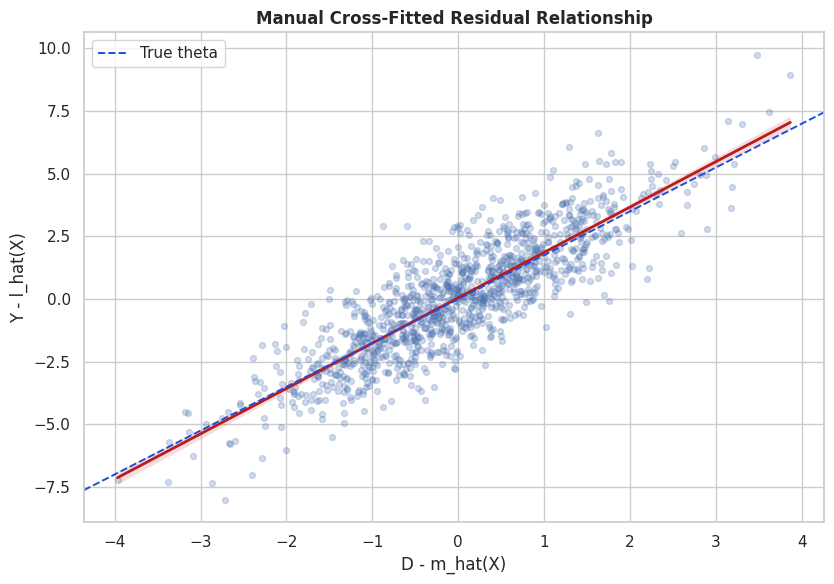

In [12]:
residual_plot_df = pd.DataFrame(
    {
        "residualized_treatment": manual_d_resid,
        "residualized_outcome": manual_y_resid,
    }
).sample(1_200, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.regplot(
    data=residual_plot_df,
    x="residualized_treatment",
    y="residualized_outcome",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#b91c1c", "linewidth": 2},
    ax=ax,
)
ax.axline((0, 0), slope=TRUE_THETA, color="#1d4ed8", linestyle="--", linewidth=1.4, label="True theta")
ax.set_title("Manual Cross-Fitted Residual Relationship")
ax.set_xlabel("D - m_hat(X)")
ax.set_ylabel("Y - l_hat(X)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_residual_relationship.png", dpi=160, bbox_inches="tight")
plt.show()


The residual cloud is centered near zero because both variables have been partialled out with respect to controls. The estimated slope is now much closer to the causal slope than the raw regression slope.

#### Build the DoubleML Data Object

`DoubleMLData` stores the roles that define the estimation problem:

- `y_col`: outcome column.
- `d_cols`: treatment column or columns.
- `x_cols`: observed controls.

The hidden teaching columns are intentionally excluded from `x_cols`. In real analysis, including post-treatment, outcome-derived, or target-leaking columns is one of the fastest ways to create a polished but invalid estimate.

In [13]:
dml_data = DoubleMLData(
    plr_df[["weekly_value", "exposure_intensity"] + feature_cols],
    y_col="weekly_value",
    d_cols="exposure_intensity",
    x_cols=feature_cols,
)

backend_summary = pd.DataFrame(
    [
        {"role": "outcome", "columns": ", ".join(dml_data.y_col if isinstance(dml_data.y_col, list) else [dml_data.y_col])},
        {"role": "treatment", "columns": ", ".join(dml_data.d_cols)},
        {"role": "controls", "columns": ", ".join(dml_data.x_cols)},
        {"role": "number_of_observations", "columns": str(dml_data.n_obs)},
    ]
)
save_table(backend_summary, "doublemldata_backend_summary")
display(backend_summary)


,role,columns
0,outcome,weekly_value
1,treatment,exposure_intensity
2,controls,"engagement_score, need_intensity, content_fit, recent_activity, price_sensitivity, tenure_signal, novelty_appetite, seasonality_signal"
3,number_of_observations,3000


This object is where the estimand becomes concrete. If the role assignment is wrong, the estimator can run perfectly and still answer the wrong question.

#### Fit `DoubleMLPLR` with Flexible Nuisance Models

We now fit two DoubleML PLR models:

- one with regularized linear nuisance learners;
- one with gradient-boosted nuisance learners.

Both use the partialling-out score and five-fold cross-fitting. The treatment-effect estimate is still a single slope, but the nuisance functions can be nonlinear.

In [14]:
# Fit or evaluate the model objects used in the Fit `DoubleMLPLR` With Flexible Nuisance Models section.
plr_models = {}

for model_name, learner in {
    "Linear nuisance PLR": linear_nuisance,
    "Gradient boosting nuisance PLR": gradient_boosting_nuisance,
}.items():
    model = DoubleMLPLR(
        dml_data,
        ml_l=clone(learner),
        ml_m=clone(learner),
        n_folds=5,
        n_rep=1,
        score="partialling out",
    )
    model.fit(store_predictions=True)
    plr_models[model_name] = model
    print(f"Finished: {model_name}")

plr_summary_rows = []
for model_name, model in plr_models.items():
    summary = model.summary.reset_index().rename(columns={"index": "treatment"})
    row = summary.iloc[0].to_dict()
    plr_summary_rows.append(
        {
            "estimator": model_name,
            "treatment": row["treatment"],
            "theta_hat": row["coef"],
            "std_error": row["std err"],
            "t_stat": row["t"],
            "p_value": row["P>|t|"],
            "ci_95_lower": row["2.5 %"],
            "ci_95_upper": row["97.5 %"],
            "true_theta": TRUE_THETA,
            "bias_vs_truth": row["coef"] - TRUE_THETA,
        }
    )

plr_summary = pd.DataFrame(plr_summary_rows)
save_table(plr_summary, "doubleml_plr_summary")
display(plr_summary)


Finished: Linear nuisance PLR


Finished: Gradient boosting nuisance PLR


,estimator,treatment,theta_hat,std_error,t_stat,p_value,ci_95_lower,ci_95_upper,true_theta,bias_vs_truth
0,Linear nuisance PLR,exposure_intensity,2.181014,0.023598,92.424000,0.0,2.134763,2.227265,1.75,0.431014
1,Gradient boosting nuisance PLR,exposure_intensity,1.803571,0.020571,87.677374,0.0,1.763254,1.843889,1.75,0.053571


The gradient-boosted nuisance model is expected to perform better here because the simulated assignment and outcome nuisance functions are nonlinear. The linear nuisance model remains useful because it shows how underfitting nuisance functions can move the final effect estimate.



#### Compare All Estimators

This table joins the simple baselines, manual cross-fitted PLR, and DoubleML estimates.

A useful habit is to compare estimators by what variation they use, more than by which package produced them. Naive OLS uses raw treatment variation. PLR uses treatment variation left after adjustment for observed controls.

In [15]:
all_estimates = pd.concat(
    [
        baseline_estimates[["estimator", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "true_theta", "bias_vs_truth"]],
        manual_plr_estimate[["estimator", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "true_theta", "bias_vs_truth"]],
        plr_summary[["estimator", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "true_theta", "bias_vs_truth"]],
    ],
    ignore_index=True,
)
all_estimates["abs_bias_vs_truth"] = all_estimates["bias_vs_truth"].abs()
save_table(all_estimates, "all_estimator_comparison")
display(all_estimates.sort_values("abs_bias_vs_truth"))

,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,true_theta,bias_vs_truth,abs_bias_vs_truth
2,Oracle residual PLR,1.773986,0.016884,1.740894,1.807078,1.75,0.023986,0.023986
3,Manual cross-fitted PLR,1.793143,0.020765,1.752444,1.833843,1.75,0.043143,0.043143
5,Gradient boosting nuisance PLR,1.803571,0.020571,1.763254,1.843889,1.75,0.053571,0.053571
4,Linear nuisance PLR,2.181014,0.023598,2.134763,2.227265,1.75,0.431014,0.431014
1,Linear adjustment OLS,2.181194,0.023565,2.135007,2.227381,1.75,0.431194,0.431194
0,Naive OLS,2.616427,0.018387,2.580390,2.652464,1.75,0.866427,0.866427


The comparison shows the intended lesson: flexible residualization can move the estimate toward the true causal slope, while naive and underfit approaches can retain confounding bias.

#### Estimate Comparison Plot

The figure below summarizes the estimator comparison with confidence intervals. The red dashed line marks the true effect used in the simulation.

For a real dataset, the same plot is still useful, but the reference line would usually be absent. The emphasis would be on how estimates change across credible specifications.

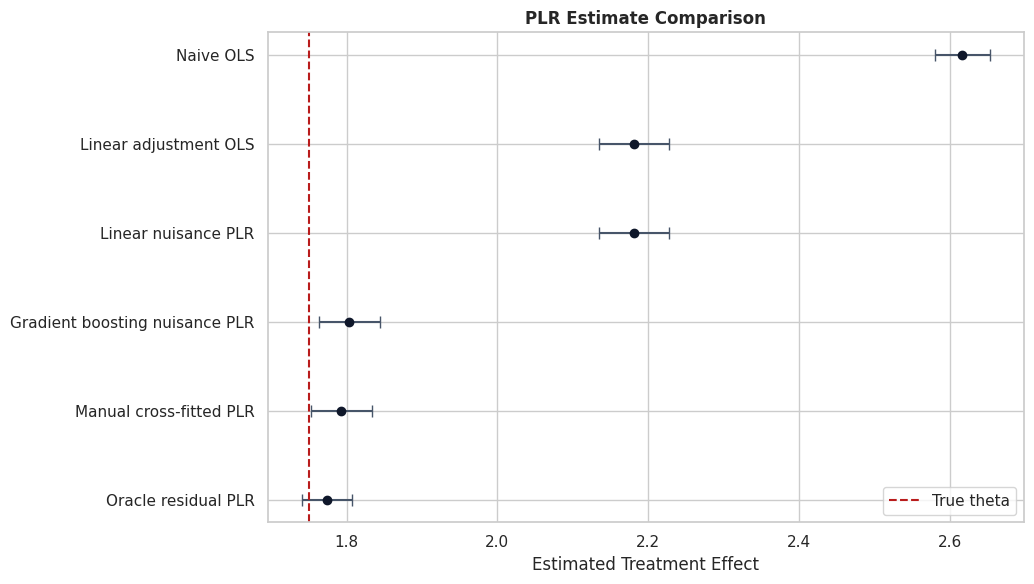

In [16]:
plot_estimates = all_estimates.copy()
plot_estimates = plot_estimates.sort_values("theta_hat")
plot_estimates["lower_error"] = plot_estimates["theta_hat"] - plot_estimates["ci_95_lower"]
plot_estimates["upper_error"] = plot_estimates["ci_95_upper"] - plot_estimates["theta_hat"]

fig, ax = plt.subplots(figsize=(10.5, 6))
y_pos = np.arange(len(plot_estimates))
ax.errorbar(
    x=plot_estimates["theta_hat"],
    y=y_pos,
    xerr=[plot_estimates["lower_error"], plot_estimates["upper_error"]],
    fmt="o",
    color="#0f172a",
    ecolor="#475569",
    capsize=4,
)
ax.axvline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.5, label="True theta")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_estimates["estimator"])
ax.set_xlabel("Estimated Treatment Effect")
ax.set_title("PLR Estimate Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_plr_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The plot is also a communication tool. It shows why the modeling choice is not cosmetic: nuisance quality changes the final causal estimate.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




### DoubleML Nuisance Losses

`evaluate_learners()` reports out-of-fold RMSE for the nuisance learners. For PLR, the two learner keys are:

- `ml_l`: outcome nuisance learner;
- `ml_m`: treatment nuisance learner.

Lower nuisance RMSE is generally helpful, but the treatment-effect estimate is not chosen by nuisance RMSE alone. A learner can predict well while still producing unstable residual variation or violating design assumptions.

In [17]:
loss_tables = []
for model_name, model in plr_models.items():
    loss_tables.append(learner_loss_table(model, model_name))

nuisance_losses = pd.concat(loss_tables, ignore_index=True)
save_table(nuisance_losses, "doubleml_nuisance_losses")
display(nuisance_losses)

,model,learner,mean_rmse,min_rmse,max_rmse
0,Linear nuisance PLR,ml_l,2.974666,2.974666,2.974666
1,Linear nuisance PLR,ml_m,1.217088,1.217088,1.217088
2,Gradient boosting nuisance PLR,ml_l,2.340982,2.340982,2.340982
3,Gradient boosting nuisance PLR,ml_m,1.119281,1.119281,1.119281


The loss table helps explain why the gradient-boosting specification is more credible in this synthetic design. It is better matched to the nonlinear treatment assignment and outcome nuisance functions.

#### Nuisance Predictions Against Truth

Because this is a simulation, we can directly compare DoubleML's out-of-fold nuisance predictions to the true nuisance functions.

The code below extracts the stored predictions from the gradient-boosted DoubleML model and computes RMSE, MAE, correlation, and observed-target R-squared.

In [18]:
plr_hgb = plr_models["Gradient boosting nuisance PLR"]
hgb_l_hat = prediction_vector(plr_hgb, "ml_l")
hgb_m_hat = prediction_vector(plr_hgb, "ml_m")

hgb_nuisance_quality = pd.DataFrame(
    [
        {
            "nuisance": "ml_l outcome nuisance",
            "rmse_vs_true_nuisance": rmse(plr_df["true_outcome_nuisance"], hgb_l_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(plr_df["true_outcome_nuisance"], hgb_l_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(plr_df["true_outcome_nuisance"], hgb_l_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(y, hgb_l_hat)),
        },
        {
            "nuisance": "ml_m treatment nuisance",
            "rmse_vs_true_nuisance": rmse(plr_df["true_treatment_nuisance"], hgb_m_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(plr_df["true_treatment_nuisance"], hgb_m_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(plr_df["true_treatment_nuisance"], hgb_m_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(d, hgb_m_hat)),
        },
    ]
)
save_table(hgb_nuisance_quality, "hgb_nuisance_quality_against_truth")
display(hgb_nuisance_quality)


,nuisance,rmse_vs_true_nuisance,mae_vs_true_nuisance,correlation_vs_true_nuisance,out_of_fold_r2_against_observed_target
0,ml_l outcome nuisance,1.064457,0.752895,0.965631,0.733968
1,ml_m treatment nuisance,0.411209,0.303679,0.947286,0.523343


The nuisance predictions are far from perfect, but they capture enough of the assignment and outcome structure to reduce the confounding bias substantially.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->




#### Visual Nuisance Diagnostics

The next figure compares predicted nuisance functions against the true nuisance functions. Again, this is possible only because the data are synthetic.

The important practical habit is the same for real data: inspect nuisance behavior instead of treating the effect estimate as a black box.

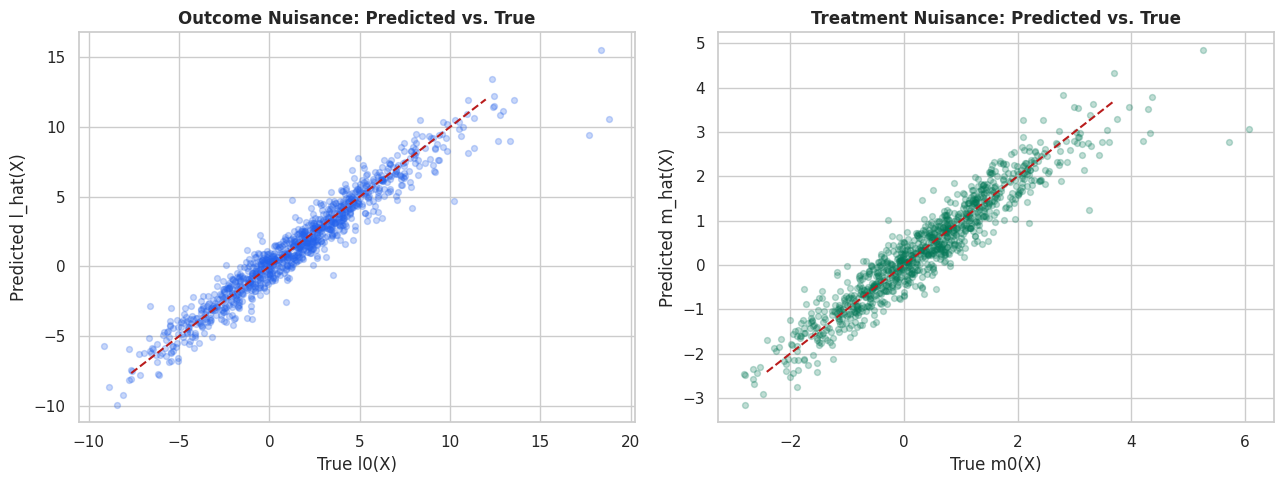

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample_idx = plr_df.sample(1_000, random_state=RANDOM_STATE).index

axes[0].scatter(plr_df.loc[sample_idx, "true_outcome_nuisance"], hgb_l_hat[sample_idx], alpha=0.25, s=18, color="#2563eb")
lims_l = [plr_df["true_outcome_nuisance"].quantile(0.01), plr_df["true_outcome_nuisance"].quantile(0.99)]
axes[0].plot(lims_l, lims_l, color="#b91c1c", linestyle="--", linewidth=1.5)
axes[0].set_title("Outcome Nuisance: Predicted vs. True")
axes[0].set_xlabel("True l0(X)")
axes[0].set_ylabel("Predicted l_hat(X)")

axes[1].scatter(plr_df.loc[sample_idx, "true_treatment_nuisance"], hgb_m_hat[sample_idx], alpha=0.25, s=18, color="#047857")
lims_m = [plr_df["true_treatment_nuisance"].quantile(0.01), plr_df["true_treatment_nuisance"].quantile(0.99)]
axes[1].plot(lims_m, lims_m, color="#b91c1c", linestyle="--", linewidth=1.5)
axes[1].set_title("Treatment Nuisance: Predicted vs. True")
axes[1].set_xlabel("True m0(X)")
axes[1].set_ylabel("Predicted m_hat(X)")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nuisance_prediction_quality.png", dpi=160, bbox_inches="tight")
plt.show()


The treatment nuisance is often especially important in PLR because residualized treatment variation forms the denominator of the score. If `m_hat(X)` leaves systematic assignment patterns in the residual, the final slope can remain biased.

#### Residual Distribution Diagnostics

The residuals used by DoubleML should have meaningful spread. If the treatment residual is nearly zero for most units, then the design has weak residual treatment variation after controlling for `X`.

The code below compares the residualized treatment and outcome distributions from the gradient-boosting DoubleML fit.

,residual,mean,std,p05,median,p95
0,Y - l_hat(X),0.014335,2.341328,-3.656194,0.016557,3.765091
1,D - m_hat(X),-0.000898,1.119467,-1.805516,-0.029860,1.808114


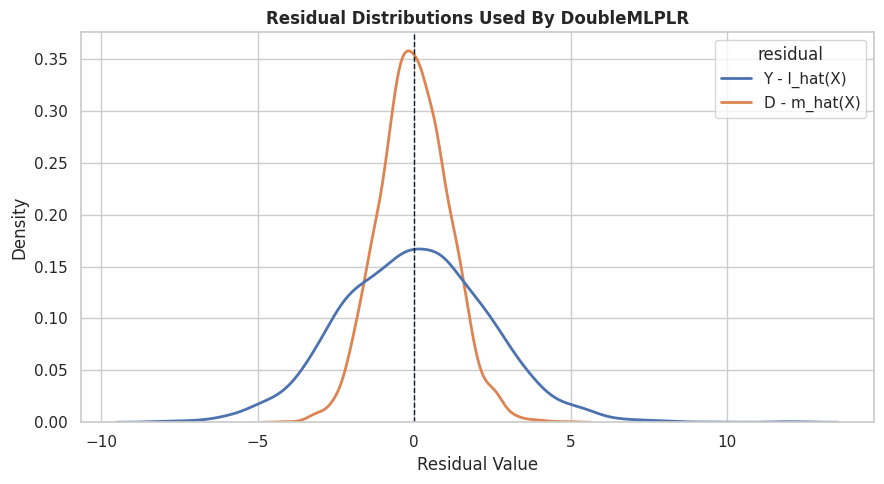

In [20]:
# Build and label the diagnostic visualization for the Residual Distribution Diagnostics section.
dml_y_resid = y - hgb_l_hat
dml_d_resid = d - hgb_m_hat

residual_summary = pd.DataFrame(
    [
        {
            "residual": "Y - l_hat(X)",
            "mean": float(np.mean(dml_y_resid)),
            "std": float(np.std(dml_y_resid, ddof=1)),
            "p05": float(np.quantile(dml_y_resid, 0.05)),
            "median": float(np.median(dml_y_resid)),
            "p95": float(np.quantile(dml_y_resid, 0.95)),
        },
        {
            "residual": "D - m_hat(X)",
            "mean": float(np.mean(dml_d_resid)),
            "std": float(np.std(dml_d_resid, ddof=1)),
            "p05": float(np.quantile(dml_d_resid, 0.05)),
            "median": float(np.median(dml_d_resid)),
            "p95": float(np.quantile(dml_d_resid, 0.95)),
        },
    ]
)
save_table(residual_summary, "dml_residual_summary")
display(residual_summary)

fig, ax = plt.subplots(figsize=(9, 5))
resid_long = pd.DataFrame(
    {
        "Y - l_hat(X)": dml_y_resid,
        "D - m_hat(X)": dml_d_resid,
    }
).melt(var_name="residual", value_name="value")
sns.kdeplot(data=resid_long, x="value", hue="residual", fill=False, common_norm=False, linewidth=2, ax=ax)
ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
ax.set_title("Residual Distributions Used By DoubleMLPLR")
ax.set_xlabel("Residual Value")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_residual_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


The residualized treatment has enough spread to estimate a slope. If it collapsed near zero, the analysis would be warning us that the observed controls nearly determine treatment, leaving little quasi-experimental variation.

#### Orthogonal Score Values

DoubleML stores the score contributions `psi`. Large or highly skewed score contributions can signal instability, influential rows, or a need for more careful diagnostics.

Here we summarize and plot the score contributions from the gradient-boosted PLR fit.

,mean,std,p01,p05,median,p95,p99
0,4.192202e-16,1.411746,-4.212317,-2.051832,-0.003355,1.992187,4.053578


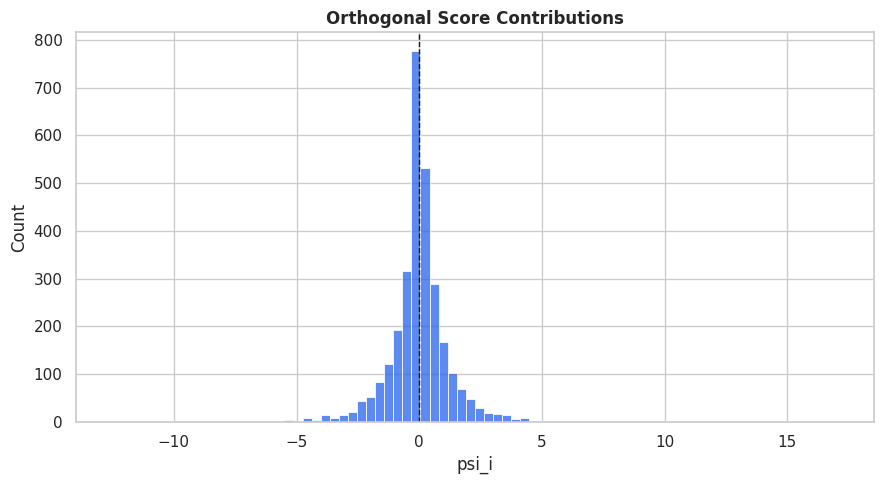

In [21]:
# Build and label the diagnostic visualization for the Orthogonal Score Values section.
psi_values = np.asarray(plr_hgb.psi)[:, 0, 0]
psi_summary = pd.DataFrame(
    [
        {
            "mean": float(np.mean(psi_values)),
            "std": float(np.std(psi_values, ddof=1)),
            "p01": float(np.quantile(psi_values, 0.01)),
            "p05": float(np.quantile(psi_values, 0.05)),
            "median": float(np.median(psi_values)),
            "p95": float(np.quantile(psi_values, 0.95)),
            "p99": float(np.quantile(psi_values, 0.99)),
        }
    ]
)
save_table(psi_summary, "orthogonal_score_summary")
display(psi_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(psi_values, bins=80, color="#2563eb", alpha=0.75, ax=ax)
ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
ax.set_title("Orthogonal Score Contributions")
ax.set_xlabel("psi_i")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_orthogonal_score_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The score is centered near zero at the fitted estimate, which is exactly what the estimating equation requires. The tails remind us that a small set of observations can still matter for uncertainty.



#### Repeated Sample Splitting

The estimate can vary slightly depending on how folds are drawn. Repeated sample splitting reruns the cross-fitting procedure under multiple splits and aggregates the result.

The code below uses a lighter gradient-boosting learner so the repeated-split check stays fast. The estimate should stay reasonably stable across split draws.

In [22]:
# Fit or evaluate the model objects used in the Repeated Sample Splitting section.
repeated_split_learner = HistGradientBoostingRegressor(
    max_iter=140,
    learning_rate=0.06,
    max_leaf_nodes=20,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

plr_repeated = DoubleMLPLR(
    dml_data,
    ml_l=clone(repeated_split_learner),
    ml_m=clone(repeated_split_learner),
    n_folds=5,
    n_rep=5,
    score="partialling out",
)
plr_repeated.fit(store_predictions=False)

split_stability = pd.DataFrame(
    {
        "repetition": np.arange(1, plr_repeated.all_coef.shape[1] + 1),
        "theta_hat": plr_repeated.all_coef[0],
        "std_error": plr_repeated.all_se[0],
    }
)
split_stability["true_theta"] = TRUE_THETA
split_stability["bias_vs_truth"] = split_stability["theta_hat"] - TRUE_THETA
save_table(split_stability, "repeated_sample_split_stability")
display(split_stability)


,repetition,theta_hat,std_error,true_theta,bias_vs_truth
0,1,1.833156,0.020712,1.75,0.083156
1,2,1.836018,0.020391,1.75,0.086018
2,3,1.827569,0.020538,1.75,0.077569
3,4,1.828953,0.020835,1.75,0.078953
4,5,1.819890,0.021275,1.75,0.069890


Small movement across repetitions is normal. Large movement would suggest unstable nuisance learning, weak residual treatment variation, or a need for more observations, different learners, or a sharper design.



#### Split Stability Plot

The next figure shows the repeated-split estimates with the true effect as a reference line. It is a quick visual check for fold sensitivity.

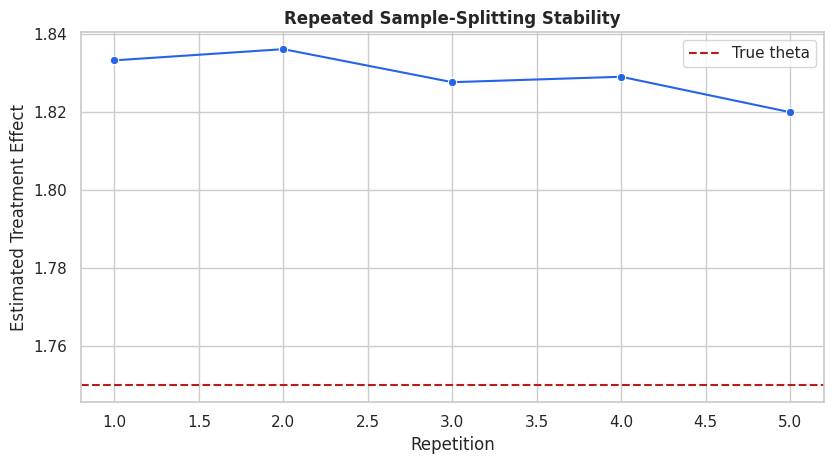

In [23]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.lineplot(data=split_stability, x="repetition", y="theta_hat", marker="o", color="#2563eb", ax=ax)
ax.axhline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.5, label="True theta")
ax.set_title("Repeated Sample-Splitting Stability")
ax.set_xlabel("Repetition")
ax.set_ylabel("Estimated Treatment Effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_repeated_split_stability.png", dpi=160, bbox_inches="tight")
plt.show()

This stability check helps detect whether the numerical estimate is fragile to the random fold split. Identification still comes from the design.

#### Bootstrap Confidence Interval

DoubleML can compute bootstrap-based inference. For a single treatment, the ordinary confidence interval and bootstrap interval are often similar, but bootstrap tools become especially useful for joint inference and multiple parameters.

We run a moderate bootstrap here to keep the tutorial fast.

In [24]:
plr_hgb.bootstrap(method="normal", n_rep_boot=500)
bootstrap_ci = plr_hgb.confint(joint=False, level=0.95).reset_index().rename(columns={"index": "treatment"})
bootstrap_ci["estimator"] = "Gradient boosting nuisance PLR bootstrap"
save_table(bootstrap_ci, "hgb_bootstrap_confidence_interval")
display(bootstrap_ci)

,treatment,2.5 %,97.5 %,estimator
0,exposure_intensity,1.763254,1.843889,Gradient boosting nuisance PLR bootstrap


The bootstrap interval is another uncertainty summary around the same identifying design. It does not address omitted variables or bad controls; it quantifies sampling uncertainty conditional on the model and assumptions.

#### A Small Sensitivity Check

PLR still relies on observed-control identification. If important unobserved variables affect both treatment and outcome, the estimate can be biased.

DoubleML includes sensitivity tools for supported models. We run a small illustrative sensitivity scenario here and save the text summary. A later notebook in this tutorial series will go deeper into sensitivity analysis.

In [25]:
plr_hgb.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0, level=0.95)
sensitivity_summary_text = str(plr_hgb.sensitivity_summary)
(REPORT_DIR / f"{NOTEBOOK_PREFIX}_hgb_sensitivity_summary.txt").write_text(sensitivity_summary_text)
print(sensitivity_summary_text)

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
                    CI lower  theta lower     theta  theta upper  CI upper
exposure_intensity   1.73751     1.771313  1.803571      1.83583  1.869727

------------------ Robustness Values ------------------
                    H_0     RV (%)    RVa (%)
exposure_intensity  0.0  78.664479  77.679603


The sensitivity output should be read as a robustness exercise, not as proof that unobserved confounding is absent. It asks how strong omitted-confounder relationships would need to be under the chosen scenario.



#### When PLR is the Wrong Tool

PLR is powerful, but it is not universal.

Use a different design when:

- The treatment is binary and the target is ATE or ATT: consider `DoubleMLIRM`.
- The treatment is endogenous even after observed controls: consider an IV design such as `DoubleMLPLIV` if a credible instrument exists.
- The effect is expected to vary strongly across groups: combine PLR with heterogeneity tools or move to a model that targets CATE/GATE/BLP explicitly.
- The data are panel, event-time, sample-selection, or discontinuity data: use the corresponding design rather than forcing a PLR setup.
- The available controls include post-treatment variables: redesign the feature set before estimating.

The estimator should follow the causal question. Do not choose PLR just because it is convenient.




## Reporting and Takeaways

### Reporting Checklist

This checklist turns the notebook into a reusable applied workflow. A credible PLR report should describe more than the estimate but also the design, role assignment, nuisance models, uncertainty, and limitations.

| item | status |
| --- | --- |
| Causal question | Stated as effect of exposure_intensity on weekly_value. |
| Treatment type | Continuous dose; PLR is appropriate for a constant-slope estimand. |
| Control timing | All controls are pre-treatment by construction in this synthetic dataset. |
| Nuisance learners | Compared regularized linear and gradient-boosted nuisance models. |
| Cross-fitting | Used five folds; manually demonstrated residualization and used DoubleMLPLR. |
| Uncertainty | Reported standard errors, confidence intervals, and a bootstrap interval. |
| Stability | Checked repeated sample splitting. |
| Sensitivity | Ran a small illustrative unobserved-confounding sensitivity scenario. |
| Main limitation | Synthetic truth is known here; real use requires defensible observed-control identification. |


The checklist is deliberately plain. Good causal reporting is often about making assumptions and diagnostics visible, not about adding more model complexity.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


### Report Template

The next cell writes a short markdown report template using the main estimate from the gradient-boosted PLR model. This can be adapted for real analyses by replacing the synthetic-data checks with design-specific evidence.

In [26]:
main_row = plr_summary.loc[plr_summary["estimator"] == "Gradient boosting nuisance PLR"].iloc[0]
report_text = f"""
# PLR Effect Estimate Report Template

## Causal Question
Estimate the constant-slope effect of `exposure_intensity` on `weekly_value`, adjusting for pre-treatment controls.

## Estimator
The main estimator is `DoubleMLPLR` with the partialling-out score, five-fold cross-fitting, and histogram gradient-boosting nuisance learners for `ml_l` and `ml_m`.

## Main Estimate
- Estimated effect: {main_row['theta_hat']:.4f}
- Standard error: {main_row['std_error']:.4f}
- 95 percent confidence interval: [{main_row['ci_95_lower']:.4f}, {main_row['ci_95_upper']:.4f}]

## Diagnostics Included
- Baseline comparisons against naive and linearly adjusted OLS.
- Manual cross-fitted residualization.
- Nuisance learner RMSE checks.
- Residual distribution checks.
- Orthogonal score contribution checks.
- Repeated sample-splitting stability.
- Bootstrap confidence interval.
- Small illustrative sensitivity analysis.

## Required Assumptions
The PLR estimate relies on observed-control identification: after adjusting for the selected pre-treatment controls, residual treatment variation is as-good-as-random for the outcome. The model does not solve omitted confounding or bad-control problems by itself.
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_plr_report_template.md"
report_path.write_text(report_text)
print(report_text)


# PLR Effect Estimate Report Template

## Causal Question
Estimate the constant-slope effect of `exposure_intensity` on `weekly_value`, adjusting for pre-treatment controls.

## Estimator
The main estimator is `DoubleMLPLR` with the partialling-out score, five-fold cross-fitting, and histogram gradient-boosting nuisance learners for `ml_l` and `ml_m`.

## Main Estimate
- Estimated effect: 1.8036
- Standard error: 0.0206
- 95 percent confidence interval: [1.7633, 1.8439]

## Diagnostics Included
- Baseline comparisons against naive and linearly adjusted OLS.
- Manual cross-fitted residualization.
- Nuisance learner RMSE checks.
- Residual distribution checks.
- Orthogonal score contribution checks.
- Repeated sample-splitting stability.
- Bootstrap confidence interval.
- Small illustrative sensitivity analysis.

## Required Assumptions
The PLR estimate relies on observed-control identification: after adjusting for the selected pre-treatment controls, residual treatment variation is as-g

This report template keeps the estimate attached to its assumptions. That is the right posture for DoubleML: the package helps estimate a design-based target, but the design itself still has to be argued.

The PLR notebook is now complete. The next natural topic is the partially linear instrumental-variable model, where the treatment may still be endogenous after observed controls and a credible instrument is needed.